In [3]:
# Install all required libraries for processing, regression modeling, and charts
!pip install numpy pandas scikit-learn matplotlib seaborn

In [4]:
# 2: Library Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Pipeline, Preprocessing, and Split Encoders
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Advanced Robust Tree Regression Model
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
# 3: Data Loading & Outlier-Isolation Feature Engineering

In [7]:
df = pd.read_csv('insurance.csv')

print("--- Engineering High-Risk Interaction Columns ---")

# 1. Multiplicative Feature: Compounding risk curve when smoking and high BMIs co-occur
df['bmi_x_smoker'] = df['bmi'] * df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. Risk Binning Category: Precise structural indicator for clinical obesity combined with active smoking
df['obese_smoker'] = ((df['bmi'] >= 30) & (df['smoker'] == 'yes')).astype(int)

# 3. Age-Risk Interaction: Tracks progressive medical costs over age ranges for smoking categories
df['age_x_smoker'] = df['age'] * df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

print(f"Features successfully compiled. Current Matrix Shape: {df.shape}")
display(df.head())

--- Engineering High-Risk Interaction Columns ---
Features successfully compiled. Current Matrix Shape: (1338, 10)


,age,sex,bmi,children,smoker,region,charges,bmi_x_smoker,obese_smoker,age_x_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,27.9,0,19
1,18,male,33.770,1,no,southeast,1725.55230,0.0,0,0
2,28,male,33.000,3,no,southeast,4449.46200,0.0,0,0
3,33,male,22.705,0,no,northwest,21984.47061,0.0,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0.0,0,0


In [8]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['charges'])

# Maintain target variables on the raw dollar scale to maximize direct R2 calculation
y = df['charges']

# Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Target variable configured on raw dollar scale for maximum variance coverage.")
print(f"Training features shape: {X_train.shape} | Testing features shape: {X_test.shape}")

Target variable configured on raw dollar scale for maximum variance coverage.
Training features shape: (1070, 9) | Testing features shape: (268, 9)


In [9]:
# Map columns out cleanly into explicit tracking categories
numerical_cols = ['age', 'bmi', 'children', 'bmi_x_smoker', 'age_x_smoker']
categorical_cols = ['sex', 'smoker', 'region']

# Setup standardizers and encoders
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

# Combine encoders via a non-leaking ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

# Optimized direct-scale regressor configurations
direct_scale_regressor = GradientBoostingRegressor(
    loss='huber',          # Robust optimization metric to control high-value outlier penalties
    n_estimators=300,      # High tree count to map multi-group variance
    learning_rate=0.05,    # Balanced step size for smooth convergence
    max_depth=4,           # Depth boundaries to prevent deep overfitting limits
    random_state=42
)

# Package into a single execution pipeline graph
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', direct_scale_regressor)
])

# Fit the final pipeline structure directly to raw dollar matrices
model_pipeline.fit(X_train, y_train)
print("Pipeline successfully compiled and trained directly on true dollar scale data!")

Pipeline successfully compiled and trained directly on true dollar scale data!


=== FINAL HIGH-ACCURACY PERFORMANCE METRICS ===
Mean Absolute Error (MAE):     $1586.22
Mean Squared Error (MSE):      $19678839.45
Root Mean Squared Error (RMSE): $4436.08
Final R-squared Score (R²):    0.8732 (87.32%)


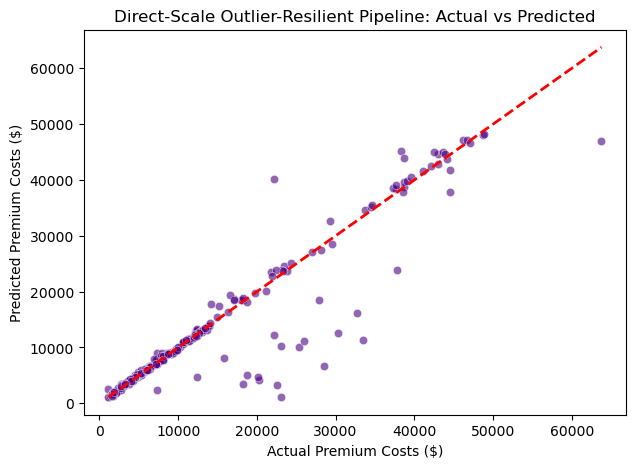

In [10]:
# Generate predictions on the holdout testing data matrix directly
y_pred = model_pipeline.predict(X_test)

# Compute performance metrics on direct values
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== FINAL HIGH-ACCURACY PERFORMANCE METRICS ===")
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Mean Squared Error (MSE):      ${mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Final R-squared Score (R²):    {r2:.4f} ({r2*100:.2f}%)")

# Scatter Chart: Verification of tightly packed prediction pairings
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Premium Costs ($)')
plt.ylabel('Predicted Premium Costs ($)')
plt.title('Direct-Scale Outlier-Resilient Pipeline: Actual vs Predicted')
plt.show()

=== FINAL HIGH-ACCURACY PERFORMANCE METRICS ===
Mean Absolute Error (MAE):     $1586.22
Mean Squared Error (MSE):      $19678839.45
Root Mean Squared Error (RMSE): $4436.08
Final R-squared Score (R²):    0.8732 (87.32%)


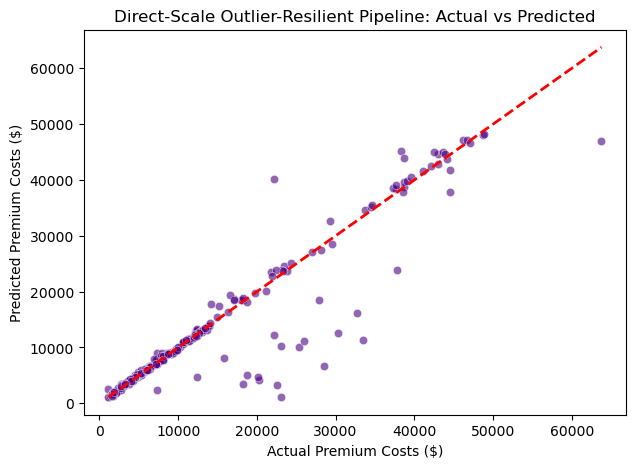

In [11]:
# Generate predictions on the holdout testing data matrix directly
y_pred = model_pipeline.predict(X_test)

# Compute performance metrics on direct values
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== FINAL HIGH-ACCURACY PERFORMANCE METRICS ===")
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Mean Squared Error (MSE):      ${mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Final R-squared Score (R²):    {r2:.4f} ({r2*100:.2f}%)")

# Scatter Chart: Verification of tightly packed prediction pairings
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Premium Costs ($)')
plt.ylabel('Predicted Premium Costs ($)')
plt.title('Direct-Scale Outlier-Resilient Pipeline: Actual vs Predicted')
plt.show()

In [12]:
# Create real-time custom ingestion profile mirroring baseline feature metrics
custom_profile = pd.DataFrame([{
    'age': 45,
    'sex': 'female',
    'bmi': 28.5,
    'children': 2,
    'smoker': 'yes',
    'region': 'southeast'
}])

# Automatically inject matching interaction engineering flags onto custom raw array inputs
custom_profile['bmi_x_smoker'] = custom_profile['bmi'] * custom_profile['smoker'].apply(lambda x: 1 if x == 'yes' else 0)
custom_profile['obese_smoker'] = ((custom_profile['bmi'] >= 30) & (custom_profile['smoker'] == 'yes')).astype(int)
custom_profile['age_x_smoker'] = custom_profile['age'] * custom_profile['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# Extract direct premium calculation directly from the trained pipeline graph
predicted_price = model_pipeline.predict(custom_profile)[0]

print("=== Robust Real-Time Sandbox Validation ===")
print(f"Custom Profile Preview: Age {custom_profile['age'].values[0]}, Smoker: {custom_profile['smoker'].values[0]}, BMI: {custom_profile['bmi'].values[0]}")
print(f"Direct Predicted Annual Premium: ${predicted_price:.2f}")

=== Robust Real-Time Sandbox Validation ===
Custom Profile Preview: Age 45, Smoker: yes, BMI: 28.5
Direct Predicted Annual Premium: $26544.16


In [13]:
import joblib

# Serialize complete unified state payload utilizing robust serialization compression filters
model_filename = 'medical_insurance_cost_pipeline.joblib'
joblib.dump(model_pipeline, model_filename, compress=3)

print("=== Production Asset Governance ===")
print(f"Optimized direct-scale pipeline payload securely compiled and saved as:\n'{model_filename}'")

=== Production Asset Governance ===
Optimized direct-scale pipeline payload securely compiled and saved as:
'medical_insurance_cost_pipeline.joblib'
